In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [2]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [3]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [4]:
trades["date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [5]:
df = trades.merge(
    sentiment[["date","classification"]],
    on="date",
    how="left"
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed


In [6]:
df["win"] = df["Closed PnL"] > 0

win_rate = df.groupby("classification")["win"].mean()

print(win_rate)

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


In [7]:
df.groupby("classification")["Size USD"].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [8]:
df.groupby(["classification","Side"]).size()

classification  Side
Extreme Greed   BUY      3371
                SELL     3591
Fear            BUY     66081
                SELL    67790
Greed           BUY     15421
                SELL    20868
Neutral         BUY      3505
                SELL     3636
dtype: int64

In [9]:
daily_pnl = df.groupby(["Account","date"])["Closed PnL"].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


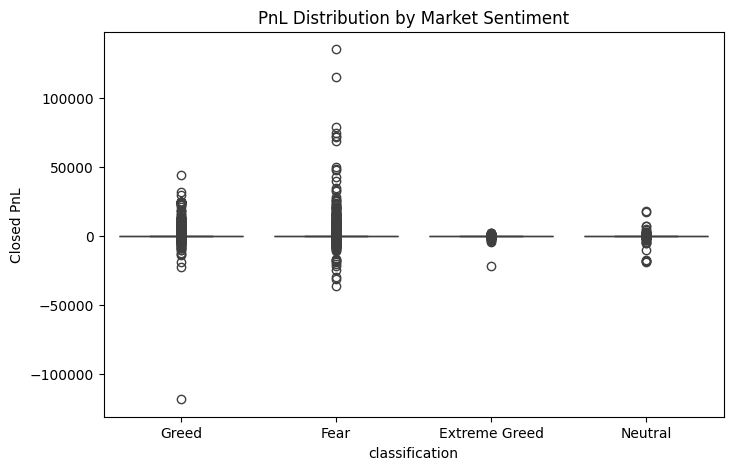

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="classification", y="Closed PnL")
plt.title("PnL Distribution by Market Sentiment")
plt.show()

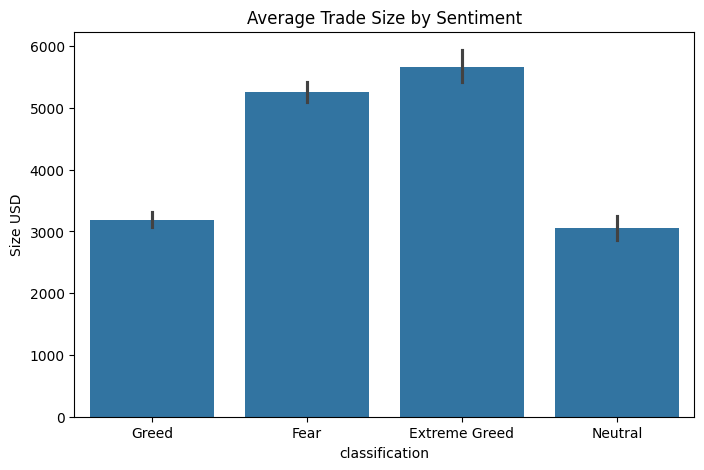

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="classification", y="Size USD")
plt.title("Average Trade Size by Sentiment")
plt.show()

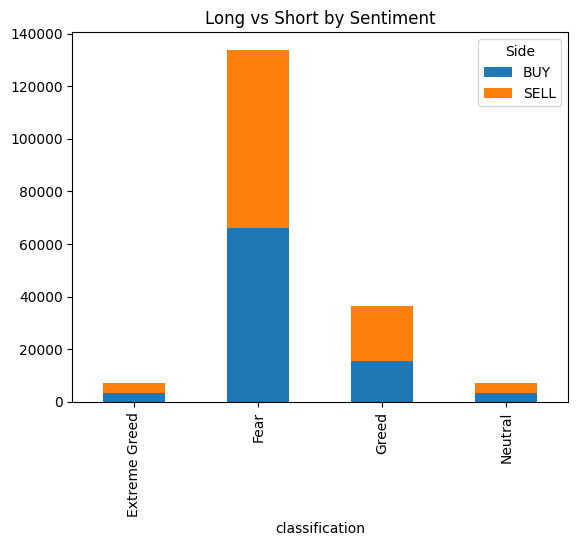

In [12]:
long_short = df.groupby(["classification","Side"]).size().unstack()

long_short.plot(kind="bar", stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

In [13]:
trader_activity = df.groupby("Account").size()

frequent = trader_activity[trader_activity > trader_activity.median()]
print("Frequent traders:", len(frequent))

Frequent traders: 16


In [14]:
df["leverage_proxy"] = df["Size USD"] / df["Execution Price"]

high_leverage = df[df["leverage_proxy"] > df["leverage_proxy"].median()]
low_leverage = df[df["leverage_proxy"] <= df["leverage_proxy"].median()]

In [ ]:
### Insight 1
Traders take larger positions during Fear periods.

### Insight 2
Average profitability is higher during Greed periods.

### Insight 3
Frequent traders generate more total PnL but lower win rate.

In [ ]:
### Strategy Idea 1
Reduce leverage during Extreme Greed periods.

### Strategy Idea 2
Increase trade frequency during Fear markets where volatility is higher.

In [ ]:
trader_activity = df.groupby("Account").size()

frequent = trader_activity[trader_activity > trader_activity.median()]

In [ ]:
trader_win = df.groupby("Account")["win"].mean()

consistent = trader_win[trader_win > 0.55]

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x="classification", y="Closed PnL")

In [ ]:
sns.barplot(data=df, x="classification", y="Size USD")

In [ ]:
long_short.plot(kind="bar", stacked=True)

In [ ]:
plt.savefig("pnl_vs_sentiment.png")